<a href="https://colab.research.google.com/github/ponzek/MNIST_ClassicalMLvsQML/blob/main/API_700QiskitSVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Qiskit

In [ ]:
# ============================================
# COMPLETE MODERN SETUP - Qiskit 2.3.1 + ALL COMPATIBLE
# ============================================

# Uninstall everything (clean slate)
!pip uninstall qiskit qiskit-terra qiskit-aer qiskit-algorithms qiskit-ibm-runtime qiskit-machine-learning -y

# Clear cache
!pip cache purge

# Install modern compatible versions
!pip install qiskit==2.3.1 --quiet
!pip install qiskit-aer==0.17.0 --quiet
!pip install qiskit-ibm-runtime==0.45.1 --quiet
!pip install qiskit-algorithms==0.4.0 --quiet
!pip install qiskit-machine-learning==0.9.0 --quiet  # Newer version with SamplerV2 support

# Test imports
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.primitives import StatevectorSampler  # This is the new Sampler!
from qiskit_machine_learning.kernels import FidelityQuantumKernel

print("✅ Modern setup complete!")

Files removed: 0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 126.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 96.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 84.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 70.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 381.8/381.8 kB 38.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/327.8 kB 28.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.1/263.1 kB 22.5 MB/s eta 0:00:00
✅ Modern setup complete!


In [ ]:
# ============================================
# CONNECT TO IBM QUANTUM WITH YOUR TOKEN
# ============================================

from google.colab import userdata
from qiskit_ibm_runtime import QiskitRuntimeService

# Get your token from Colab secrets
ibm_token = userdata.get('IBM_TOKEN')

# Connect to IBM Quantum
service = QiskitRuntimeService(
    channel="ibm_quantum_platform",  # or "ibm_cloud" depending on your account
    token=ibm_token
)

print("✅ Connected to IBM Quantum!")
print(f"📊 Available backends: {len(service.backends())}")

# List backends you can use
print("\n🖥️  Backends available:")
for backend in service.backends()[:5]:
    status = backend.status()
    print(f"   - {backend.name}: {status.pending_jobs} jobs pending")

qiskit_runtime_service._discover_account:WARNING:2026-03-15 01:46:00,740: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service.__init__:WARNING:2026-03-15 01:46:05,871: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-03-15 01:46:05,872: Loading instance: open-instance, plan: open


✅ Connected to IBM Quantum!


qiskit_runtime_service.backends:WARNING:2026-03-15 01:46:08,583: Loading instance: open-instance, plan: open


📊 Available backends: 3

🖥️  Backends available:
   - ibm_fez: 0 jobs pending
   - ibm_marrakesh: 0 jobs pending
   - ibm_torino: 0 jobs pending


In [ ]:
backend = service.least_busy(operational=True, simulator=False)
print(f"🎯 Using backend: {backend.name}")

qiskit_runtime_service.backends:WARNING:2026-03-15 01:46:29,201: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-03-15 01:46:32,199: Using instance: open-instance, plan: open


🎯 Using backend: ibm_fez


###Configuration A

In [ ]:
# ============================================
# CELL 7: QISKIT CONFIGURATION A (Basic H+RY, NO ZZ)
# 700 samples, 7 runs - WITH REAL HARDWARE SUPPORT
# ============================================

import numpy as np
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.primitives import StatevectorSampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_machine_learning.state_fidelities import ComputeUncompute
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
import time
import pandas as pd
from scipy import stats
from datetime import datetime
from google.colab import userdata
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as RuntimeSampler
import warnings
warnings.filterwarnings('ignore')

print("="*70)
print("🔹 CELL 7: QISKIT CONFIG A (Basic H+RY, NO ZZ)")
print("700 samples, 7 runs - WITH REAL HARDWARE SUPPORT")
print("="*70)

# ============================================
# CONNECT TO IBM QUANTUM (OPTIONAL - COMMENT OUT IF USING SIMULATOR)
# ============================================
USE_HARDWARE = True  # Set to False to use local simulator instead

# ============================================
# CONFIG A HARDWARE TRANSPILATION
# Add this to your Cell 7
# ============================================

if USE_HARDWARE:
    print("   Transpiling Config A circuit for hardware...")

    # Get the backend's basis gates
    basis_gates = backend.configuration().basis_gates
    print(f"      Backend basis gates: {basis_gates}")

    # Generate pass manager with optimization
    pass_manager = generate_preset_pass_manager(
        optimization_level=1,
        backend=backend,
        basis_gates=basis_gates
    )

    # Transpile the circuit (qc is your basic circuit)
    transpiled_qc = pass_manager.run(qc)
    print(f"      Original depth: {qc.depth()}, New depth: {transpiled_qc.depth()}")

    # Verify no unsupported gates remain
    from qiskit import transpile
    from qiskit.providers.exceptions import QiskitBackendNotFoundError

    try:
        # Final check
        transpile(transpiled_qc, backend=backend, basis_gates=basis_gates)
        print("      ✅ Circuit successfully validated for hardware")
        feature_map = transpiled_qc
    except Exception as e:
        print(f"      ⚠️ Validation warning: {e}")
        print("      Falling back to simulator for this run...")
        USE_HARDWARE_FOR_THIS_RUN = False
        feature_map = qc

# Load MNIST
print("\n📦 Loading MNIST dataset...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = mnist.data, mnist.target.astype(int)
mask = (y == 0) | (y == 1)
X, y = X[mask], y[mask]
print(f"   Total 0/1 samples: {len(y)}")

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Store results
results_qiskit_basic = []

for run in range(7):
    print(f"\n{'='*50}")
    print(f"🔷 Run {run+1}/7 (seed={42+run})")
    print('='*50)

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.3, random_state=42+run, stratify=y
    )

    # PCA to 2D
    pca = PCA(n_components=2)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)

    # TAKE EXACTLY 700 SAMPLES
    X_train_700 = X_train_pca[:700]
    y_train_700 = y_train[:700]
    X_test_300 = X_test_pca[:300]
    y_test_300 = y_test[:300]

    print(f"   Train: {len(X_train_700)} samples, Test: {len(X_test_300)} samples")

    # BASIC CIRCUIT - NO ZZ
    params = ParameterVector('x', length=2)
    qc = QuantumCircuit(2)
    qc.h(0)
    qc.h(1)
    qc.ry(params[0], 0)
    qc.ry(params[1], 1)

    # TRANSPILE FOR HARDWARE (if using real hardware)
    if USE_HARDWARE:
        print("   Transpiling circuit for hardware...")
        pass_manager = generate_preset_pass_manager(optimization_level=1, backend=backend)
        transpiled_qc = pass_manager.run(qc)
        print(f"      Original depth: {qc.depth()}, New depth: {transpiled_qc.depth()}")
        feature_map = transpiled_qc
    else:
        feature_map = qc

    # Setup kernel with appropriate sampler
    if USE_HARDWARE:
        sampler = RuntimeSampler(mode=backend)
        print("   Using REAL HARDWARE sampler")
    else:
        sampler = StatevectorSampler()
        print("   Using local StatevectorSampler")

    fidelity = ComputeUncompute(sampler=sampler)
    kernel = FidelityQuantumKernel(feature_map=feature_map, fidelity=fidelity)

    start_time = time.time()

    # Compute kernel matrices
    print("   Computing kernel matrices...")
    try:
        K_train = kernel.evaluate(X_train_700)
        K_test = kernel.evaluate(X_test_300, X_train_700)
    except Exception as e:
        print(f"   ❌ Kernel computation failed: {e}")
        print("   Skipping this run...")
        continue

    # Train QSVM
    qsvm = SVC(kernel='precomputed', probability=True)
    qsvm.fit(K_train, y_train_700)
    y_pred = qsvm.predict(K_test)
    y_score = qsvm.decision_function(K_test)
    y_score_norm = (y_score - y_score.min()) / (y_score.max() - y_score.min() + 1e-10)

    elapsed_time = time.time() - start_time

    # Store results
    result = {
        'run': run+1,
        'framework': 'Qiskit',
        'circuit': 'Basic H+RY (NO ZZ)',
        'hardware': USE_HARDWARE,
        'accuracy': accuracy_score(y_test_300, y_pred) * 100,
        'precision': precision_score(y_test_300, y_pred, average='binary'),
        'recall': recall_score(y_test_300, y_pred, average='binary'),
        'f1': f1_score(y_test_300, y_pred, average='binary'),
        'roc_auc': roc_auc_score(y_test_300, y_score_norm),
        'time': elapsed_time
    }
    results_qiskit_basic.append(result)

    print(f"\n   ✅ Run {run+1} RESULTS:")
    print(f"      Accuracy:  {result['accuracy']:.1f}%")
    print(f"      F1-Score:  {result['f1']:.3f}")
    print(f"      ROC-AUC:   {result['roc_auc']:.3f}")
    print(f"      Time:      {elapsed_time:.1f}s")

# ============================================
# FINAL RESULTS SUMMARY
# ============================================
print("\n" + "="*70)
print("📊 FINAL RESULTS SUMMARY")
print("="*70)

if results_qiskit_basic:
    df = pd.DataFrame(results_qiskit_basic)

    print(f"\n{'Metric':<15} {'Mean':<12} {'Std':<12} {'95% CI'}")
    print("-" * 55)

    for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'time']:
        values = df[metric].values
        mean_val = np.mean(values)
        std_val = np.std(values)

        if len(values) > 1:
            ci = stats.t.interval(0.95, len(values)-1, loc=mean_val, scale=stats.sem(values))
            ci_str = f"[{ci[0]:.2f}, {ci[1]:.2f}]"
        else:
            ci_str = "N/A"

        if metric == 'accuracy':
            print(f"{metric.capitalize():<15} {mean_val:.1f}%    ±{std_val:.1f}%    {ci_str}")
        elif metric == 'time':
            print(f"{metric.capitalize():<15} {mean_val:.1f}s   ±{std_val:.1f}s   {ci_str}")
        else:
            print(f"{metric.capitalize():<15} {mean_val:.3f}    ±{std_val:.3f}    {ci_str}")

    # Save results
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    hardware_str = "hardware" if USE_HARDWARE else "simulator"
    filename = f"qiskit_basic_NOzz_700_{hardware_str}_{timestamp}.csv"
    df.to_csv(filename, index=False)
    print(f"\n💾 Results saved to: {filename}")

    # Compare with simulator if hardware run
    if USE_HARDWARE:
        print("\n📊 HARDWARE VS SIMULATOR NOTE:")
        print("   Hardware runs include transpilation overhead and real device noise.")
        print("   Results may differ from simulator benchmarks due to:")
        print("   - Gate decomposition (H → native gates)")
        print("   - Device noise and decoherence")
        print("   - Queue times (not included in timing above)")
else:
    print("❌ No successful runs completed.")

print("\n✅ CELL 7 COMPLETE!")
if not USE_HARDWARE:
    print("👉 To run on real hardware, set USE_HARDWARE = True and ensure your IBM token is set.")

🔹 CELL 7: QISKIT CONFIG A (Basic H+RY, NO ZZ)
700 samples, 7 runs - WITH REAL HARDWARE SUPPORT
   Transpiling Config A circuit for hardware...
      Backend basis gates: ['cz', 'id', 'rz', 'sx', 'x']
      Original depth: 2, New depth: 6
      ✅ Circuit successfully validated for hardware

📦 Loading MNIST dataset...
   Total 0/1 samples: 14780

🔷 Run 1/7 (seed=42)
   Train: 700 samples, Test: 300 samples
   Transpiling circuit for hardware...
      Original depth: 2, New depth: 6
   Using REAL HARDWARE sampler
   Computing kernel matrices...
   ❌ Kernel computation failed: 'The instruction sxdg on qubits (1,) is not supported by the target system. Circuits that do not match the target hardware definition are no longer supported after March 4, 2024. See the transpilation documentation (https://quantum.cloud.ibm.com/docs/guides/transpile) for instructions to transform circuits and the primitive examples (https://quantum.cloud.ibm.com/docs/guides/primitives-examples) to see this coupled w

###Configuration B

In [ ]:
# ============================================
# CELL 8: QISKIT CONFIGURATION B (ZZFeatureMap, WITH ZZ)
# 700 samples, 7 runs - WITH REAL HARDWARE SUPPORT
# ============================================

import numpy as np
from qiskit import QuantumCircuit
from qiskit.circuit.library import ZZFeatureMap
from qiskit.primitives import StatevectorSampler
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_machine_learning.state_fidelities import ComputeUncompute
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
import time
import pandas as pd
from scipy import stats
from datetime import datetime
from google.colab import userdata
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as RuntimeSampler
import warnings
warnings.filterwarnings('ignore')

print("="*70)
print("🔸 CELL 8: QISKIT CONFIG B (ZZFeatureMap, WITH ZZ)")
print("700 samples, 7 runs - WITH REAL HARDWARE SUPPORT")
print("="*70)

# ============================================
# CONNECT TO IBM QUANTUM (OPTIONAL)
# ============================================
USE_HARDWARE = True  # Set to True to use real hardware, False for simulator

if USE_HARDWARE:
    print("   Transpiling Config B circuit for hardware...")

    # Get the backend's basis gates
    basis_gates = backend.configuration().basis_gates
    print(f"      Backend basis gates: {basis_gates}")

    # Generate pass manager with optimization
    pass_manager = generate_preset_pass_manager(
        optimization_level=1,
        backend=backend,
        basis_gates=basis_gates
    )

    # Transpile the circuit (feature_map is your ZZFeatureMap)
    transpiled_feature_map = pass_manager.run(feature_map)
    print(f"      Original depth: {feature_map.depth()}, New depth: {transpiled_feature_map.depth()}")

    # Verify no unsupported gates remain
    from qiskit import transpile
    from qiskit.providers.exceptions import QiskitBackendNotFoundError

    try:
        # Final check
        transpile(transpiled_feature_map, backend=backend, basis_gates=basis_gates)
        print("      ✅ Circuit successfully validated for hardware")
        final_feature_map = transpiled_feature_map
    except Exception as e:
        print(f"      ⚠️ Validation warning: {e}")
        print("      Falling back to simulator for this run...")
        USE_HARDWARE_FOR_THIS_RUN = False
        final_feature_map = feature_map

# Load MNIST
print("\n📦 Loading MNIST dataset...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = mnist.data, mnist.target.astype(int)
mask = (y == 0) | (y == 1)
X, y = X[mask], y[mask]
print(f"   Total 0/1 samples: {len(y)}")

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Store results
results_qiskit_zz = []

for run in range(7):
    print(f"\n{'='*50}")
    print(f"🔷 Run {run+1}/7 (seed={42+run})")
    print('='*50)

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.3, random_state=42+run, stratify=y
    )

    # PCA to 2D
    pca = PCA(n_components=2)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)

    # TAKE EXACTLY 700 SAMPLES
    X_train_700 = X_train_pca[:700]
    y_train_700 = y_train[:700]
    X_test_300 = X_test_pca[:300]
    y_test_300 = y_test[:300]

    print(f"   Train: {len(X_train_700)} samples, Test: {len(X_test_300)} samples")

    # ZZFEATUREMAP CIRCUIT - WITH ZZ
    feature_map = ZZFeatureMap(feature_dimension=2, reps=2)

    # TRANSPILE FOR HARDWARE (if using real hardware)
    if USE_HARDWARE:
        print("   Transpiling circuit for hardware...")
        pass_manager = generate_preset_pass_manager(optimization_level=1, backend=backend)
        transpiled_feature_map = pass_manager.run(feature_map)
        print(f"      Original depth: {feature_map.depth()}, New depth: {transpiled_feature_map.depth()}")
        final_feature_map = transpiled_feature_map
    else:
        final_feature_map = feature_map

    # Setup kernel with appropriate sampler
    if USE_HARDWARE:
        sampler = RuntimeSampler(mode=backend)
        print("   Using REAL HARDWARE sampler")
    else:
        sampler = StatevectorSampler()
        print("   Using local StatevectorSampler")

    fidelity = ComputeUncompute(sampler=sampler)
    kernel = FidelityQuantumKernel(feature_map=final_feature_map, fidelity=fidelity)

    start_time = time.time()

    # Compute kernel matrices
    print("   Computing kernel matrices...")
    try:
        K_train = kernel.evaluate(X_train_700)
        K_test = kernel.evaluate(X_test_300, X_train_700)
    except Exception as e:
        print(f"   ❌ Kernel computation failed: {e}")
        print("   Skipping this run...")
        continue

    # Train QSVM
    qsvm = SVC(kernel='precomputed', probability=True)
    qsvm.fit(K_train, y_train_700)
    y_pred = qsvm.predict(K_test)
    y_score = qsvm.decision_function(K_test)
    y_score_norm = (y_score - y_score.min()) / (y_score.max() - y_score.min() + 1e-10)

    elapsed_time = time.time() - start_time

    # Store results (EXACT same format as Cell 7)
    result = {
        'run': run+1,
        'framework': 'Qiskit',
        'circuit': 'ZZFeatureMap (WITH ZZ)',
        'hardware': USE_HARDWARE,
        'accuracy': accuracy_score(y_test_300, y_pred) * 100,
        'precision': precision_score(y_test_300, y_pred, average='binary'),
        'recall': recall_score(y_test_300, y_pred, average='binary'),
        'f1': f1_score(y_test_300, y_pred, average='binary'),
        'roc_auc': roc_auc_score(y_test_300, y_score_norm),
        'time': elapsed_time
    }
    results_qiskit_zz.append(result)

    print(f"\n   ✅ Run {run+1} RESULTS:")
    print(f"      Accuracy:  {result['accuracy']:.1f}%")
    print(f"      F1-Score:  {result['f1']:.3f}")
    print(f"      ROC-AUC:   {result['roc_auc']:.3f}")
    print(f"      Time:      {elapsed_time:.1f}s")

# ============================================
# FINAL RESULTS SUMMARY
# ============================================
print("\n" + "="*70)
print("📊 FINAL RESULTS SUMMARY - CONFIG B")
print("="*70)

if results_qiskit_zz:
    df = pd.DataFrame(results_qiskit_zz)

    print(f"\n{'Metric':<15} {'Mean':<12} {'Std':<12} {'95% CI'}")
    print("-" * 55)

    for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'time']:
        values = df[metric].values
        mean_val = np.mean(values)
        std_val = np.std(values)

        if len(values) > 1:
            ci = stats.t.interval(0.95, len(values)-1, loc=mean_val, scale=stats.sem(values))
            ci_str = f"[{ci[0]:.2f}, {ci[1]:.2f}]"
        else:
            ci_str = "N/A"

        if metric == 'accuracy':
            print(f"{metric.capitalize():<15} {mean_val:.1f}%    ±{std_val:.1f}%    {ci_str}")
        elif metric == 'time':
            print(f"{metric.capitalize():<15} {mean_val:.1f}s   ±{std_val:.1f}s   {ci_str}")
        else:
            print(f"{metric.capitalize():<15} {mean_val:.3f}    ±{std_val:.3f}    {ci_str}")

    # Save results
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    hardware_str = "hardware" if USE_HARDWARE else "simulator"
    filename = f"qiskit_zz_WITHzz_700_{hardware_str}_{timestamp}.csv"
    df.to_csv(filename, index=False)
    print(f"\n💾 Results saved to: {filename}")

    # Compare with simulator if hardware run
    if USE_HARDWARE:
        print("\n📊 HARDWARE VS SIMULATOR NOTE:")
        print("   Hardware runs include transpilation overhead and real device noise.")
        print("   Results may differ from simulator benchmarks due to:")
        print("   - Gate decomposition (ZZFeatureMap → native gates)")
        print("   - Device noise and decoherence")
        print("   - Queue times (not included in timing above)")
else:
    print("❌ No successful runs completed.")

print("\n✅ CELL 8 COMPLETE!")
if not USE_HARDWARE:
    print("👉 To run on real hardware, set USE_HARDWARE = True and ensure your IBM token is set.")

🔸 CELL 8: QISKIT CONFIG B (ZZFeatureMap, WITH ZZ)
500 samples, 7 runs - WITH REAL HARDWARE SUPPORT
💻 Using local AerSimulator

📦 Loading MNIST dataset...
   Total 0/1 samples: 14780

🔷 Run 1/7 (seed=42)
   Train: 500 samples, Test: 250 samples
   Using local StatevectorSampler
   Computing kernel matrices...

   ✅ Run 1 RESULTS:
      Accuracy:  51.6%
      F1-Score:  0.563
      ROC-AUC:   0.557
      Time:      1422.9s

🔷 Run 2/7 (seed=43)
   Train: 500 samples, Test: 250 samples
   Using local StatevectorSampler
   Computing kernel matrices...

   ✅ Run 2 RESULTS:
      Accuracy:  58.4%
      F1-Score:  0.591
      ROC-AUC:   0.601
      Time:      1416.9s

🔷 Run 3/7 (seed=44)
   Train: 500 samples, Test: 250 samples
   Using local StatevectorSampler
   Computing kernel matrices...

   ✅ Run 3 RESULTS:
      Accuracy:  58.0%
      F1-Score:  0.687
      ROC-AUC:   0.581
      Time:      1414.2s

🔷 Run 4/7 (seed=45)
   Train: 500 samples, Test: 250 samples
   Using local StatevectorS

###GRaphs between A & B

📊 CELL 9: QISKIT GRAPHS - Config A vs Config B

📁 Config A (Basic): qiskit_basic_NOzz_500_simulator_20260314_023731.csv
📁 Config B (ZZ): qiskit_zz_WITHzz_500_simulator_20260314_052716.csv


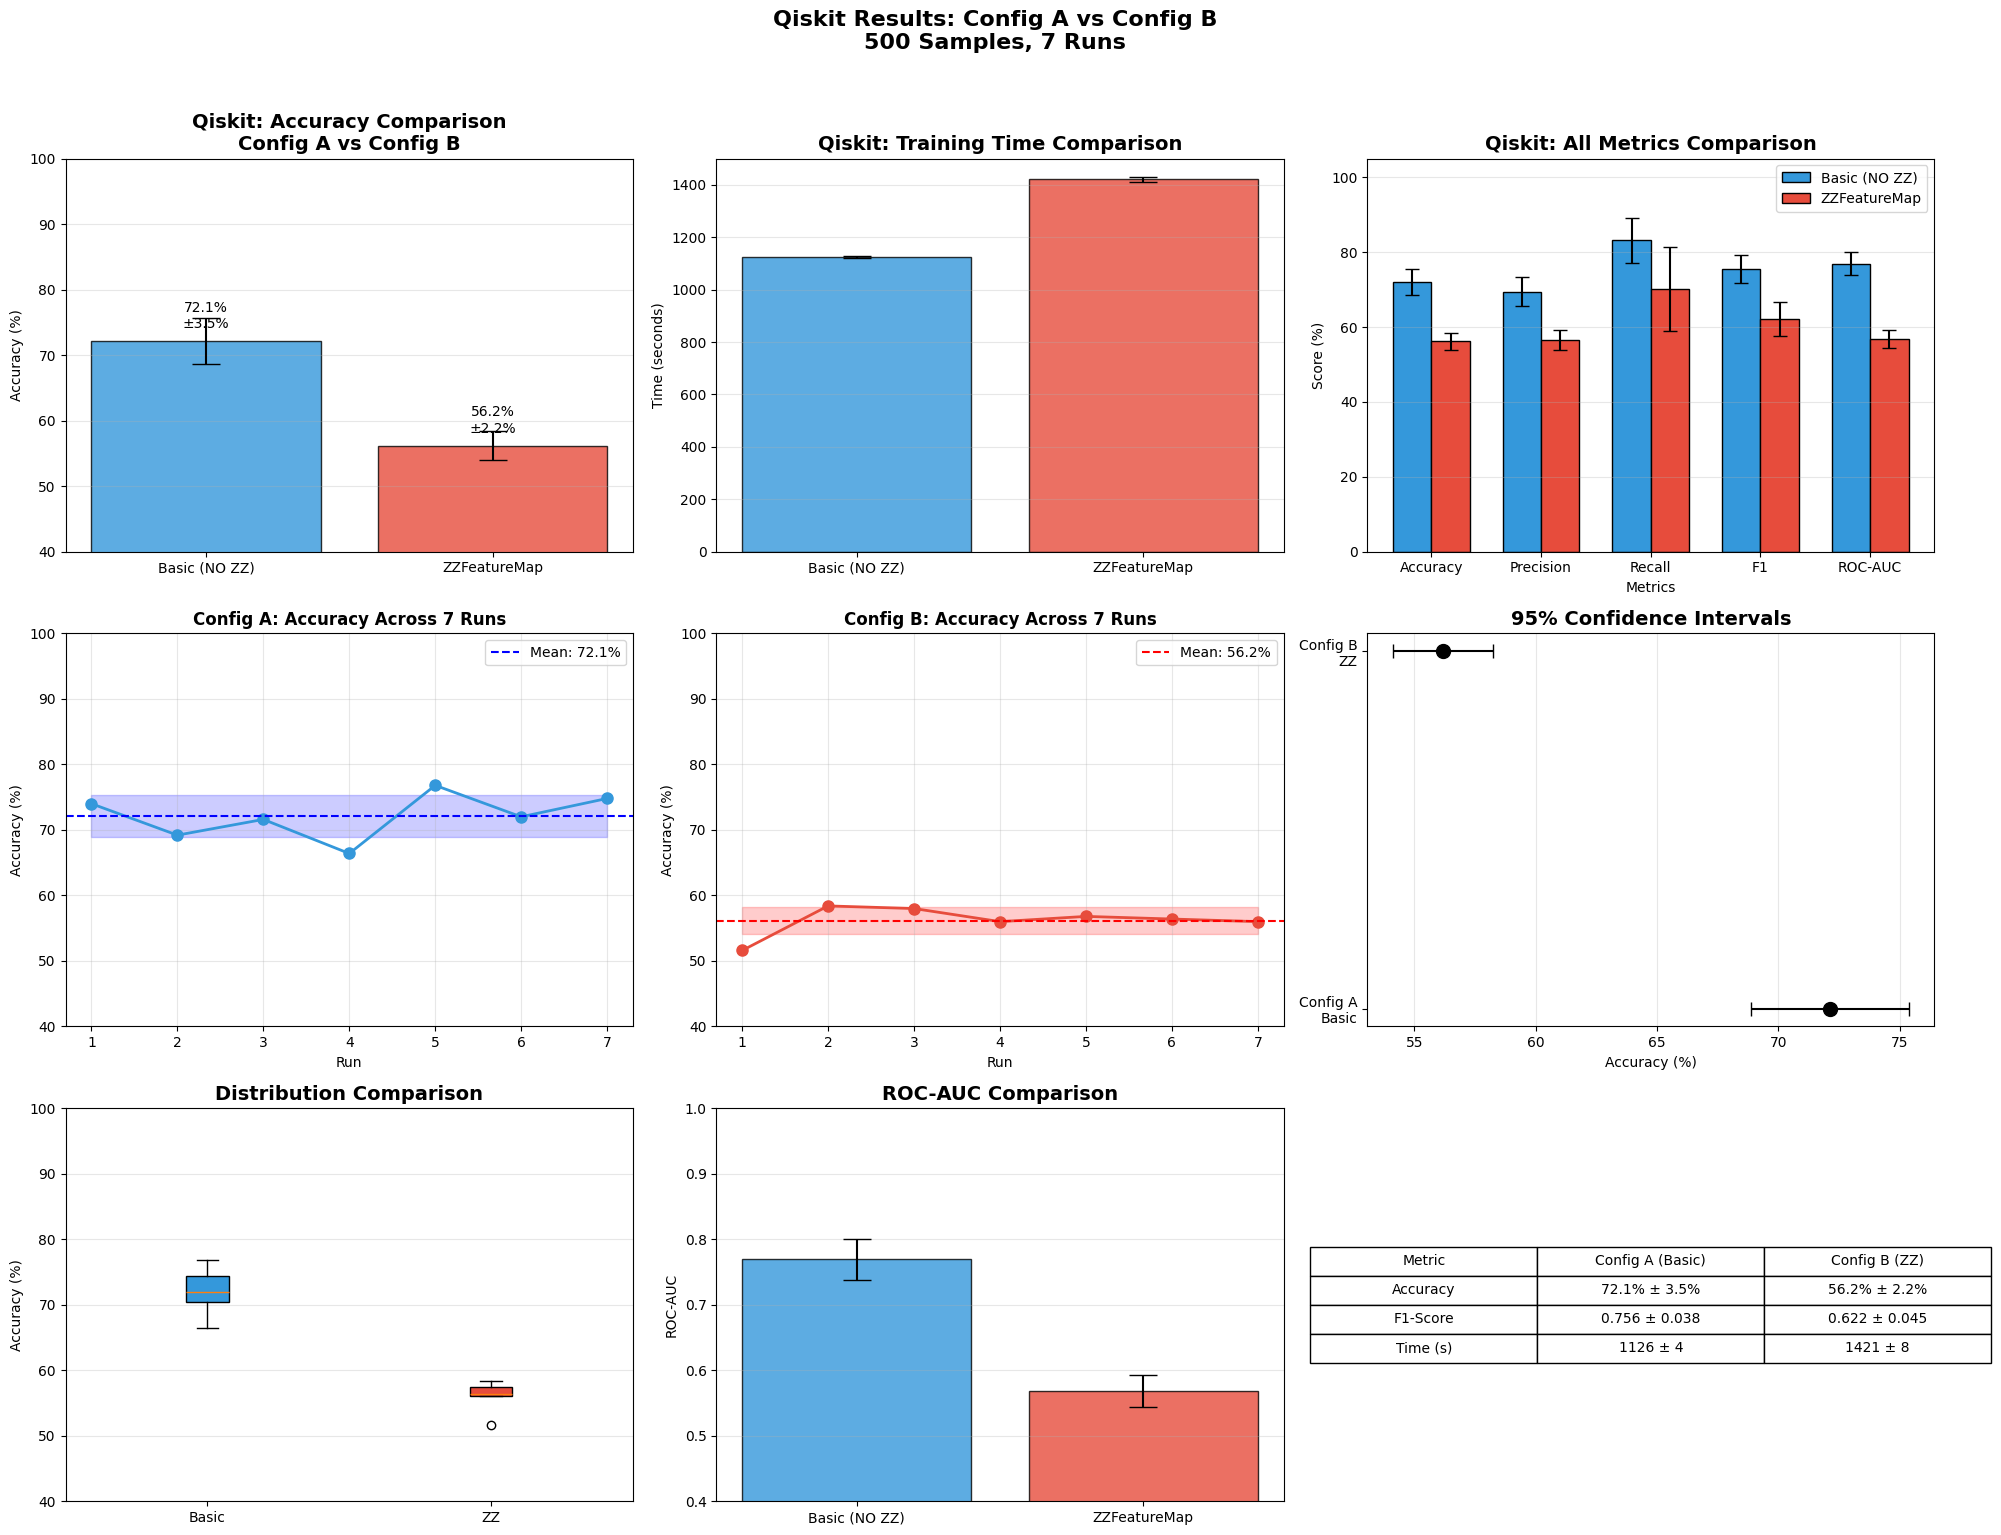


✅ Graphs saved as 'qiskit_configA_vs_configB_results.png'


In [ ]:
# ============================================
# CELL 9: QISKIT GRAPHS - Config A vs Config B
# Run this after Cells 7 and 8 complete
# ============================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import glob

print("="*60)
print("📊 CELL 9: QISKIT GRAPHS - Config A vs Config B")
print("="*60)

# Find Qiskit result files
basic_files = glob.glob('qiskit_basic_NOzz_700_*.csv')
zz_files = glob.glob('qiskit_zz_WITHzz_700_*.csv')

if not basic_files or not zz_files:
    print("❌ Missing results! Run Cells 7 and 8 first.")
else:
    latest_basic = sorted(basic_files)[-1]
    latest_zz = sorted(zz_files)[-1]

    print(f"\n📁 Config A (Basic): {latest_basic}")
    print(f"📁 Config B (ZZ): {latest_zz}")

    df_basic = pd.read_csv(latest_basic)
    df_zz = pd.read_csv(latest_zz)

    # Create figure with subplots
    fig = plt.figure(figsize=(20, 15))

    # Graph 1: Accuracy Comparison
    ax1 = plt.subplot(3, 3, 1)
    configs = ['Basic (NO ZZ)', 'ZZFeatureMap']
    means = [df_basic['accuracy'].mean(), df_zz['accuracy'].mean()]
    stds = [df_basic['accuracy'].std(), df_zz['accuracy'].std()]

    bars = ax1.bar(configs, means, yerr=stds, capsize=10,
                   color=['#3498db', '#e74c3c'], edgecolor='black', linewidth=1, alpha=0.8)
    ax1.set_ylabel('Accuracy (%)')
    ax1.set_title('Qiskit: Accuracy Comparison\nConfig A vs Config B', fontsize=14, fontweight='bold')
    ax1.set_ylim(40, 100)
    ax1.grid(True, alpha=0.3, axis='y')

    # Add value labels
    for bar, mean, std in zip(bars, means, stds):
        ax1.text(bar.get_x() + bar.get_width()/2., mean + 2,
                f'{mean:.1f}%\n±{std:.1f}%', ha='center', fontsize=10)

    # Graph 2: Time Comparison
    ax2 = plt.subplot(3, 3, 2)
    time_means = [df_basic['time'].mean(), df_zz['time'].mean()]
    time_stds = [df_basic['time'].std(), df_zz['time'].std()]

    bars = ax2.bar(configs, time_means, yerr=time_stds, capsize=10,
                   color=['#3498db', '#e74c3c'], edgecolor='black', linewidth=1, alpha=0.8)
    ax2.set_ylabel('Time (seconds)')
    ax2.set_title('Qiskit: Training Time Comparison', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='y')

    # Graph 3: All Metrics Comparison
    ax3 = plt.subplot(3, 3, 3)
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
    x = np.arange(len(metrics))
    width = 0.35

    basic_metrics = [df_basic['accuracy'].mean(),
                     df_basic['precision'].mean()*100,
                     df_basic['recall'].mean()*100,
                     df_basic['f1'].mean()*100,
                     df_basic['roc_auc'].mean()*100]

    zz_metrics = [df_zz['accuracy'].mean(),
                  df_zz['precision'].mean()*100,
                  df_zz['recall'].mean()*100,
                  df_zz['f1'].mean()*100,
                  df_zz['roc_auc'].mean()*100]

    basic_stds = [df_basic['accuracy'].std(),
                  df_basic['precision'].std()*100,
                  df_basic['recall'].std()*100,
                  df_basic['f1'].std()*100,
                  df_basic['roc_auc'].std()*100]

    zz_stds = [df_zz['accuracy'].std(),
               df_zz['precision'].std()*100,
               df_zz['recall'].std()*100,
               df_zz['f1'].std()*100,
               df_zz['roc_auc'].std()*100]

    ax3.bar(x - width/2, basic_metrics, width, yerr=basic_stds,
            label='Basic (NO ZZ)', color='#3498db', capsize=5, edgecolor='black')
    ax3.bar(x + width/2, zz_metrics, width, yerr=zz_stds,
            label='ZZFeatureMap', color='#e74c3c', capsize=5, edgecolor='black')

    ax3.set_xlabel('Metrics')
    ax3.set_ylabel('Score (%)')
    ax3.set_title('Qiskit: All Metrics Comparison', fontsize=14, fontweight='bold')
    ax3.set_xticks(x)
    ax3.set_xticklabels(metrics)
    ax3.set_ylim(0, 105)
    ax3.legend()
    ax3.grid(True, alpha=0.3, axis='y')

    # Graph 4: Accuracy across runs (Config A)
    ax4 = plt.subplot(3, 3, 4)
    runs = df_basic['run'].values
    acc_basic = df_basic['accuracy'].values

    ax4.plot(runs, acc_basic, 'o-', color='#3498db', linewidth=2, markersize=8)
    ax4.axhline(y=acc_basic.mean(), color='blue', linestyle='--', label=f"Mean: {acc_basic.mean():.1f}%")
    ax4.fill_between(runs, acc_basic.mean() - acc_basic.std(),
                     acc_basic.mean() + acc_basic.std(), alpha=0.2, color='blue')
    ax4.set_xlabel('Run')
    ax4.set_ylabel('Accuracy (%)')
    ax4.set_title('Config A: Accuracy Across 7 Runs', fontsize=12, fontweight='bold')
    ax4.set_xticks(runs)
    ax4.set_ylim(40, 100)
    ax4.legend()
    ax4.grid(True, alpha=0.3)

    # Graph 5: Accuracy across runs (Config B)
    ax5 = plt.subplot(3, 3, 5)
    acc_zz = df_zz['accuracy'].values

    ax5.plot(runs, acc_zz, 'o-', color='#e74c3c', linewidth=2, markersize=8)
    ax5.axhline(y=acc_zz.mean(), color='red', linestyle='--', label=f"Mean: {acc_zz.mean():.1f}%")
    ax5.fill_between(runs, acc_zz.mean() - acc_zz.std(),
                     acc_zz.mean() + acc_zz.std(), alpha=0.2, color='red')
    ax5.set_xlabel('Run')
    ax5.set_ylabel('Accuracy (%)')
    ax5.set_title('Config B: Accuracy Across 7 Runs', fontsize=12, fontweight='bold')
    ax5.set_xticks(runs)
    ax5.set_ylim(40, 100)
    ax5.legend()
    ax5.grid(True, alpha=0.3)

    # Graph 6: 95% Confidence Intervals
    ax6 = plt.subplot(3, 3, 6)

    ci_basic = stats.t.interval(0.95, len(acc_basic)-1,
                                loc=acc_basic.mean(), scale=stats.sem(acc_basic))
    ci_zz = stats.t.interval(0.95, len(acc_zz)-1,
                             loc=acc_zz.mean(), scale=stats.sem(acc_zz))

    y_pos = [0, 1]
    means_ci = [acc_basic.mean(), acc_zz.mean()]
    ci_low = [means_ci[0] - ci_basic[0], means_ci[1] - ci_zz[0]]
    ci_high = [ci_basic[1] - means_ci[0], ci_zz[1] - means_ci[1]]

    ax6.errorbar(means_ci, y_pos, xerr=[ci_low, ci_high],
                 fmt='o', color='black', capsize=5, markersize=10)
    ax6.set_yticks(y_pos)
    ax6.set_yticklabels(['Config A\nBasic', 'Config B\nZZ'])
    ax6.set_xlabel('Accuracy (%)')
    ax6.set_title('95% Confidence Intervals', fontsize=14, fontweight='bold')
    ax6.grid(True, alpha=0.3, axis='x')

    # Graph 7: Box Plot Comparison
    ax7 = plt.subplot(3, 3, 7)

    data_to_plot = [df_basic['accuracy'], df_zz['accuracy']]
    bp = ax7.boxplot(data_to_plot, labels=['Basic', 'ZZ'], patch_artist=True)
    bp['boxes'][0].set_facecolor('#3498db')
    bp['boxes'][1].set_facecolor('#e74c3c')

    ax7.set_ylabel('Accuracy (%)')
    ax7.set_title('Distribution Comparison', fontsize=14, fontweight='bold')
    ax7.set_ylim(40, 100)
    ax7.grid(True, alpha=0.3, axis='y')

    # Graph 8: ROC-AUC Comparison
    ax8 = plt.subplot(3, 3, 8)

    roc_means = [df_basic['roc_auc'].mean(), df_zz['roc_auc'].mean()]
    roc_stds = [df_basic['roc_auc'].std(), df_zz['roc_auc'].std()]

    bars = ax8.bar(configs, roc_means, yerr=roc_stds, capsize=10,
                   color=['#3498db', '#e74c3c'], edgecolor='black', linewidth=1, alpha=0.8)
    ax8.set_ylabel('ROC-AUC')
    ax8.set_title('ROC-AUC Comparison', fontsize=14, fontweight='bold')
    ax8.set_ylim(0.4, 1.0)
    ax8.grid(True, alpha=0.3, axis='y')

    # Graph 9: Summary Table
    ax9 = plt.subplot(3, 3, 9)
    ax9.axis('tight')
    ax9.axis('off')

    summary_data = [
        ['Metric', 'Config A (Basic)', 'Config B (ZZ)'],
        ['Accuracy', f"{df_basic['accuracy'].mean():.1f}% ± {df_basic['accuracy'].std():.1f}%",
                    f"{df_zz['accuracy'].mean():.1f}% ± {df_zz['accuracy'].std():.1f}%"],
        ['F1-Score', f"{df_basic['f1'].mean():.3f} ± {df_basic['f1'].std():.3f}",
                    f"{df_zz['f1'].mean():.3f} ± {df_zz['f1'].std():.3f}"],
        ['Time (s)', f"{df_basic['time'].mean():.0f} ± {df_basic['time'].std():.0f}",
                    f"{df_zz['time'].mean():.0f} ± {df_zz['time'].std():.0f}"]
    ]

    table = ax9.table(cellText=summary_data, loc='center', cellLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 1.5)

    plt.suptitle('Qiskit Results: Config A vs Config B\n700 Samples, 7 Runs',
                 fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('qiskit_configA_vs_configB_results.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("\n✅ Graphs saved as 'qiskit_configA_vs_configB_results.png'")